<a href="https://colab.research.google.com/github/Adyypower/Deep-learning-Models-or-topics/blob/main/localization__model_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
try:
  %tensorflow_version 2.x
except Exception:
  pass

import tensorflow as tf
print(tf.__version__)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
2.19.0


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras.preprocessing import image

In [6]:
vgg = tf.keras.applications.VGG16(
    input_shape = [100,100,3],include_top = False,weights = 'imagenet'
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [7]:
x = Flatten()(vgg.output)
x = Dense(4,activation = 'sigmoid')(x)
model = Model(vgg.input,x)

In [8]:
def image_generator(batch_size = 64):
  while True:
    for _ in range(batch_size):
      x = np.zeros((batch_size,100,100,3))
      y = np.zeros((batch_size,4))

      for i in range(batch_size):
        row0 = np.random.randint(0,90)
        col0 = np.random.randint(0,90)
        row1 = np.random.randint(row0,100)
        col1 = np.random.randint(col0,100)
        x[i,row0:row1,col0:col1,:] = 1
        y[i,0] = row0/100.
        y[i,1] = col0/100.
        y[i,2] = (row1 - row0)/100.
        y[i,3] = (col1 - col0)/100
      yield x,y

In [9]:
model.compile(loss = 'binary_crossentropy',optimizer = Adam(learning_rate = 0.001))

In [ ]:
model.fit(image_generator(),steps_per_epoch = 50,epochs = 5)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 219ms/step - loss: 0.6704
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 222ms/step - loss: 0.5326
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 225ms/step - loss: 0.5101
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 230ms/step - loss: 0.5056
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 234ms/step - loss: 0.5078


In [10]:
from matplotlib.patches import Rectangle
def make_prediction():
  x = np.zeros((100,100,3))
  row0 = np.random.randint(90)
  col0 = np.random.randint(90)
  row1 = np.random.randint(row0,100)
  col1 = np.random.randint(col0,100)
  x[row0:row1,col0:col1,:] = 1

  # predict
  x_expend = np.expand_dims(x,0)
  p = model.predict(x_expend)[0]

  # Draw the box

  fig,ax = plt.subplots(1)
  ax.imshow(x)
  rect = Rectangle(
      (p[1]*100,p[0]*100),
       p[3]*100 , p[2]*100,linewidth = 1,edgecolor = 'r',facecolor = 'none')

  ax.add_patch(rect)
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


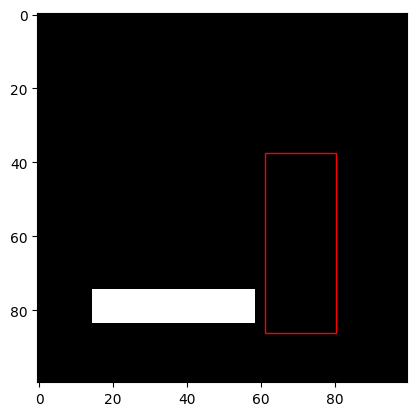

In [16]:
make_prediction()

In [17]:
from tensorflow.keras.preprocessing import image

In [18]:
!wget -nc https://lazyprogrammer.me/course_files/charmander-tight.png

--2025-08-31 06:55:12--  https://lazyprogrammer.me/course_files/charmander-tight.png
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3031::6815:17d2, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3952 (3.9K) [image/png]
Saving to: ‘charmander-tight.png’

charmander-tight.pn 100%[===================>]   3.86K  --.-KB/s    in 0s      

2025-08-31 06:55:13 (64.5 MB/s) - ‘charmander-tight.png’ saved [3952/3952]



In [19]:
!ls

charmander-tight.png  sample_data


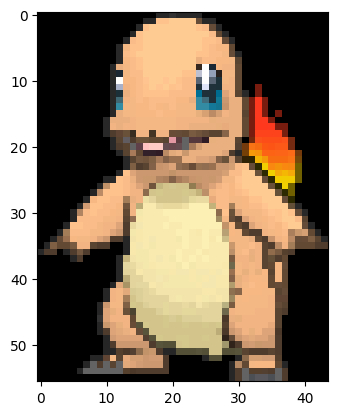

In [20]:
ch = image.load_img('charmander-tight.png')

plt.imshow(ch)
plt.show()

In [ ]:
np.array(ch).shape

(56, 44, 3)

In [21]:
from imageio import imread

/tmp/ipython-input-599271760.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  ch = imread('charmander-tight.png')


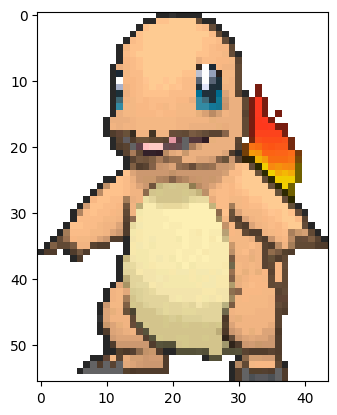

In [22]:
ch = imread('charmander-tight.png')
plt.imshow(ch)

In [23]:
type(ch)

numpy.ndarray

In [24]:
ch.shape

(56, 44, 4)

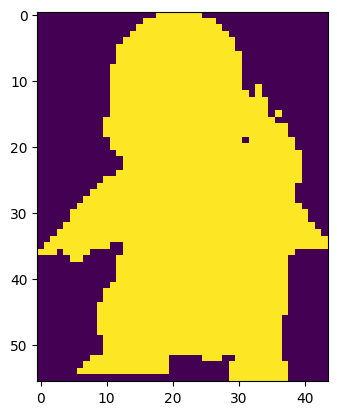

In [25]:
# what is in the 4th channel ?

plt.imshow(ch[:,:,3])
plt.show()

In [26]:
poke_dim = 200
ch = np.array(ch)
ch_h,ch_w,_= ch.shape
def pokemon_generator(batch_size = 64):

  # generate image and labels
  while True:
     for _ in range(batch_size):
      x = np.zeros((batch_size,poke_dim,poke_dim,3))
      y = np.zeros((batch_size,4))
      for i in range(batch_size):
        row0 = np.random.randint( poke_dim - ch_h)
        col0 = np.random.randint( poke_dim - ch_w)
        row1 = row0 + ch_h
        col1 = col0 +ch_w
        # Use the alpha channel to create a 3-channel mask
        mask = np.stack([ch[:,:,3]]*3, axis=-1) > 0
        # Apply the mask to the RGB channels and place it on the background
        x[i,row0:row1,col0:col1,:] = ch[:,:,:3] * mask

        y[i,0] = row0/poke_dim
        y[i,1] = col0/poke_dim

        #later: make the pokemon diffrent sizes

        y[i,2] = (row1 - row0)/poke_dim
        y[i,3] = (col1 - col0)/poke_dim
      yield x/255.,y

In [52]:
from tensorflow.keras.losses import binary_crossentropy
def custom_loss(y_true,y_pred):
  # target is a 5 tuple
  # (row,col,height,width,object_appeard)
  bce = binary_crossentropy(y_true[:,4],y_pred[:,4]) # Corrected slicing
  bce2 = binary_crossentropy(y_true[:,:4],y_pred[:,:4]) # Corrected slicing
  return 2*bce*y_true[:,4] + 0.5*bce2 # Corrected slicing

In [54]:
def make_model():
  vgg = tf.keras.applications.VGG16(
    input_shape = [poke_dim,poke_dim,3],include_top = False,weights = 'imagenet')
  x = Flatten()(vgg.output)
  x = Dense(5,activation = 'sigmoid')(x) # Changed units to 5
  model = Model(vgg.input,x)
  model.compile(loss = custom_loss,optimizer = Adam(learning_rate = 0.001))
  return model

In [ ]:
model = make_model()
model.fit(
    pokemon_generator(),steps_per_epoch = 50,epochs = 5
)

NameError: name 'poke_dim' is not defined

In [ ]:
# Make prediction

def pokemon_prediction():
  x = np.zeros((poke_dim,poke_dim,3))
  row0 = np.random.randint(poke_dim - ch_h)
  col0 = np.random.randint(poke_dim - ch_w)
  row1 = row0 + ch_h
  col1 = col0 + ch_w
  # Use the alpha channel to create a 3-channel mask
  mask = np.stack([ch[:,:,3]]*3, axis=-1) > 0
  # Apply the mask to the RGB channels and place it on the background
  x[row0:row1,col0:col1,:] = ch[:,:,:3] * mask
  print('true:',row0,col0,row1,col1)

  #predict

  x_expanded = np.expand_dims(x,0)/255.
  p = model.predict(x_expanded)[0]


  #calculate target /loss

  y = np.zeros(4)
  y[0] = row0/poke_dim
  y[1] = col0/poke_dim
  y[2] = (row1 - row0)/poke_dim
  y[3] = (col1 - col0)/poke_dim

  #draw the box

  row0 = int(p[0]*poke_dim)
  col0 = int(p[1]*poke_dim)
  row1 = int(row0 +p[2]*poke_dim)
  col1 = int(col0 +p[3]*poke_dim)
  print('pred:',row0,col0,row1,col1)
  print('loss:', -np.mean(y*np.log(p) + (1-y)*np.log(1-p)))

  fig,ax = plt.subplots(1)
  ax.imshow(x.astype(np.uint8))
  rect = Rectangle(
      (p[1]*poke_dim,p[0]*poke_dim),
      p[3]*poke_dim,p[ 2]*poke_dim,linewidth = 1,edgecolor = 'r',facecolor = 'none')
  ax.add_patch(rect)
  plt.show()

In [ ]:
pokemon_prediction()

In [29]:
from skimage.transform import resize

def pokemon_generator_with_resize(batch_size = 64):
  # generate image and target

  while True:
    for _ in range(50):
      x = np.zeros((batch_size,poke_dim,poke_dim,3))
      y = np.zeros((batch_size,4))
      for i in range(batch_size):
        #resize charmander - make it bigger or smaller

        scale = 0.5 + np.random.random()
        new_height = int(ch_h*scale)
        new_width = int(ch_w*scale)
        obj = resize(
            ch,
            (new_height,new_width),
            preserve_range = True).astype(np.uint8)
        row0 = np.random.randint(poke_dim - new_height)
        col0 = np.random.randint(poke_dim - new_width)
        row1 = row0 + new_height
        col1 = col0 +new_width
        # Use the alpha channel to create a 3-channel mask
        mask = np.stack([obj[:,:,3]]*3, axis=-1) > 0
        # Apply the mask to the RGB channels and place it on the background
        x[i,row0:row1,col0:col1,:] = obj[:,:,:3] * mask
        y[i,0] = row0/poke_dim
        y[i,1] = col0/poke_dim

        #later: make the pokemon diffrent sizes

        y[i,2] = (row1 - row0)/poke_dim
        y[i,3] = (col1 - col0)/poke_dim
      yield x/255.,y

In [30]:
def make_model2():
  vgg = tf.keras.applications.VGG16(
      input_shape = [poke_dim,poke_dim,3],
      include_top = False,
      weights = 'imagenet'
  )
  x = Flatten()(vgg.output)
  x = Dense(4,activation='sigmoid')(x)
  model = Model(vgg.input,x)

  model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy')
  return model

In [ ]:
model = make_model2()
model.fit(
    pokemon_generator_with_resize(),steps_per_epoch=50,epochs=5
)

Epoch 1/5


KeyboardInterrupt: 

In [31]:
from skimage.transform import resize

def pokemon_prediction_with_resize():
  scale = 0.5 + np.random.random()
  new_height = int(ch_h*scale)
  new_width = int(ch_w*scale)
  obj = resize(
        ch,
        (new_height,new_width),
        preserve_range = True).astype(np.uint8)
  x = np.zeros((poke_dim,poke_dim,3))
  row0 = np.random.randint(poke_dim - new_height)
  col0 = np.random.randint(poke_dim - new_width)
  row1 = row0 + new_height
  col1 = col0 + new_width
   # Use the alpha channel to create a 3-channel mask
  mask = np.stack([obj[:,:,3]]*3, axis=-1) > 0
   # Apply the mask to the RGB channels and place it on the background
  x[row0:row1,col0:col1,:] = obj[:,:,:3] * mask
  print('true:',row0,col0,row1,col1)
  #predict
  x_expanded = np.expand_dims(x,0)/255.
  p = model.predict(x_expanded)[0]

  # draw box
  row0_pred = int(p[0]*poke_dim)
  col0_pred = int(p[1]*poke_dim)
  row1_pred = int(row0_pred + p[2]*poke_dim)
  col1_pred = int(col0_pred + p[3]*poke_dim)
  print('pred:',row0_pred,col0_pred,row1_pred,col1_pred)
  #print('loss:', -np.mean(y*np.log(p) + (1-y)*np.log(1-p)))

  fig,ax = plt.subplots(1)
  ax.imshow(x.astype(np.uint8))
  rect = Rectangle(
      (p[1]*poke_dim,p[0]*poke_dim),
      p[3]*poke_dim,p[ 2]*poke_dim,linewidth = 1,edgecolor = 'r',facecolor = 'none')
  ax.add_patch(rect)
  plt.show()

In [32]:
pokemon_prediction_with_resize()

true: 69 110 138 164


InvalidArgumentError: Graph execution error:

Detected at node functional_1/dense_1/MatMul defined at (most recent call last):
<stack traces unavailable>
Matrix size-incompatible: In[0]: [1,18432], In[1]: [4608,4]

Stack trace for op definition: 
File "<frozen runpy>", line 198, in _run_module_as_main
File "<frozen runpy>", line 88, in _run_code
File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 205, in start
File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once
File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
File "/usr/local/lib/python3.12/dist-packages/ipyk

In [33]:
from skimage.transform import resize

def pokemon_generator_flip(batch_size = 64):
  # generate image and target

  while True:
    for _ in range(50):
      x = np.zeros((batch_size,poke_dim,poke_dim,3))
      y = np.zeros((batch_size,4))
      for i in range(batch_size):
        # maybe flip
        if np.random.random()<0.5:
          obj = np.fliplr(ch)
        else:
          obj = ch

        #resize the pokemon - make it bigger or smaller
        scale = 0.5 + np.random.random()
        new_height = int(ch_h*scale)
        new_width = int(ch_w*scale)
        obj = resize(
            obj, # Resize the potentially flipped image
            (new_height,new_width),
            preserve_range = True).astype(np.uint8)

        row0 = np.random.randint(poke_dim - new_height)
        col0 = np.random.randint(poke_dim - new_width)
        row1 = row0 + new_height
        col1 = col0 +new_width


        # Use the alpha channel to create a 3-channel mask
        mask = np.stack([obj[:,:,3]]*3, axis=-1) > 0
        # Apply the mask to the RGB channels and place it on the background
        x[i,row0:row1,col0:col1,:] = obj[:,:,:3] * mask
        y[i,0] = row0/poke_dim
        y[i,1] = col0/poke_dim

        #later: make the pokemon diffrent sizes

        y[i,2] = (row1 - row0)/poke_dim
        y[i,3] = (col1 - col0)/poke_dim
      yield x/255.,y

In [ ]:
model = make_model()
model.fit(pokemon_generator_flip(),steps_per_epoch = 50,epochs = 5)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 107s 778ms/step - loss: 1.5291
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 772ms/step - loss: 0.5559
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 774ms/step - loss: 0.5468
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 774ms/step - loss: 0.5410
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 773ms/step - loss: 0.5425


In [34]:
from skimage.transform import resize

def pokemon_prediction_with_flip():
  scale = 0.5 + np.random.random()
  new_height = int(ch_h*scale)
  new_width = int(ch_w*scale)
  if np.random.random()<0.5:
          obj = np.fliplr(ch)
  else:
          obj = ch
  obj = resize(
        ch,
        (new_height,new_width),
        preserve_range = True).astype(np.uint8)
  x = np.zeros((poke_dim,poke_dim,3))
  row0 = np.random.randint(poke_dim - new_height)
  col0 = np.random.randint(poke_dim - new_width)
  row1 = row0 + new_height
  col1 = col0 + new_width
   # Use the alpha channel to create a 3-channel mask
  mask = np.stack([obj[:,:,3]]*3, axis=-1) > 0
   # Apply the mask to the RGB channels and place it on the background
  x[row0:row1,col0:col1,:] = obj[:,:,:3] * mask
  print('true:',row0,col0,row1,col1)
  #predict
  x_expanded = np.expand_dims(x,0)/255.
  p = model.predict(x_expanded)[0]

  # draw box
  row0_pred = int(p[0]*poke_dim)
  col0_pred = int(p[1]*poke_dim)
  row1_pred = int(row0_pred + p[2]*poke_dim)
  col1_pred = int(col0_pred + p[3]*poke_dim)
  print('pred:',row0_pred,col0_pred,row1_pred,col1_pred)
  #print('loss:', -np.mean(y*np.log(p) + (1-y)*np.log(1-p)))

  fig,ax = plt.subplots(1)
  ax.imshow(x.astype(np.uint8))
  rect = Rectangle(
      (p[1]*poke_dim,p[0]*poke_dim),
      p[3]*poke_dim,p[ 2]*poke_dim,linewidth = 1,edgecolor = 'r',facecolor = 'none')
  ax.add_patch(rect)
  plt.show()

In [35]:
pokemon_prediction_with_flip()

true: 131 163 168 192


InvalidArgumentError: Graph execution error:

Detected at node functional_1/dense_1/MatMul defined at (most recent call last):
<stack traces unavailable>
Matrix size-incompatible: In[0]: [1,18432], In[1]: [4608,4]

Stack trace for op definition: 
File "<frozen runpy>", line 198, in _run_module_as_main
File "<frozen runpy>", line 88, in _run_code
File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 205, in start
File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once
File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
File "/usr/local/lib/python3.12/dist-packages/ipyk

In [36]:
!wget -nc https://lazyprogrammer.me/course_files/backgrounds.zip

--2025-08-31 06:56:00--  https://lazyprogrammer.me/course_files/backgrounds.zip
Resolving lazyprogrammer.me (lazyprogrammer.me)... 104.21.23.210, 172.67.213.166, 2606:4700:3030::ac43:d5a6, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|104.21.23.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 494000 (482K) [application/zip]
Saving to: ‘backgrounds.zip’

backgrounds.zip     100%[===================>] 482.42K   667KB/s    in 0.7s    

2025-08-31 06:56:01 (667 KB/s) - ‘backgrounds.zip’ saved [494000/494000]



In [37]:
!unzip -n backgrounds.zip

Archive:  backgrounds.zip
   creating: backgrounds/
  inflating: backgrounds/8.jpg       
   creating: __MACOSX/
   creating: __MACOSX/backgrounds/
  inflating: __MACOSX/backgrounds/._8.jpg  
  inflating: backgrounds/9.jpg       
  inflating: __MACOSX/backgrounds/._9.jpg  
  inflating: backgrounds/14.jpg      
  inflating: __MACOSX/backgrounds/._14.jpg  
  inflating: backgrounds/15.jpg      
  inflating: __MACOSX/backgrounds/._15.jpg  
  inflating: backgrounds/12.jpg      
  inflating: __MACOSX/backgrounds/._12.jpg  
  inflating: backgrounds/13.jpg      
  inflating: __MACOSX/backgrounds/._13.jpg  
  inflating: backgrounds/11.jpg      
  inflating: __MACOSX/backgrounds/._11.jpg  
  inflating: backgrounds/10.jpg      
  inflating: __MACOSX/backgrounds/._10.jpg  
  inflating: backgrounds/4.jpg       
  inflating: __MACOSX/backgrounds/._4.jpg  
  inflating: backgrounds/5.jpg       
  inflating: __MACOSX/backgrounds/._5.jpg  
  inflating: backgrounds/7.jpg       
  inflating: __MACOSX/back

In [38]:
from glob import glob

backgrounds = []

backgrounds_files = glob('backgrounds/*.jpg')

for f in backgrounds_files:
  bg = np.array(image.load_img(f))
  backgrounds.append(bg)

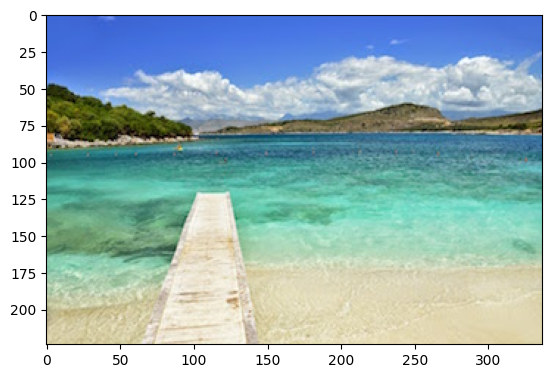

In [39]:
plt.imshow(backgrounds[3])

In [42]:
def pokemon_generator_bg(batch_size = 64):
  while True:
    for _ in range(50):
      x = np.zeros((batch_size,poke_dim,poke_dim,3))
      y = np.zeros((batch_size,5)) # Changed size to 5
      for i in range(batch_size):
        # select a random background
       bg_idx = np.random.choice(len(backgrounds))
       bg = backgrounds[bg_idx]
       bg_h,bg_w,_ = bg.shape
       rnd_h = np.random.randint(bg_h - poke_dim)
       rnd_w = np.random.randint(bg_w - poke_dim)
       x[i] = bg[rnd_h:rnd_h+poke_dim,rnd_w:rnd_w+poke_dim].copy()

       appear = (np.random.random()<0.5)
       if appear:
         # resize charmander - make it bigger or smaller
         scale = 0.5 + np.random.random()
         new_height = int(ch_h*scale)
         new_width = int(ch_w*scale)
         obj = resize(
             ch,
             (new_height,new_width),
             preserve_range = True).astype(np.uint8)
         if np.random.random()<0.5:
          obj = np.fliplr(obj)

       # choose a random location to store the object

         row0 = np.random.randint(poke_dim - new_height)
         col0 = np.random.randint(poke_dim - new_width)
         row1 = row0+new_height
         col1 = col0+new_width


       # can`t just assign obj to slice of x
       #slice the transparent parts will be black(0)

       # Use the alpha channel to blend the pokemon with the background
         alpha = obj[:,:,3] / 255.0  # Normalize alpha to be between 0 and 1
         alpha = np.stack([alpha]*3, axis=-1) # Expand alpha to 3 channels

         bg_slice = x[i,row0:row1,col0:col1,:]
         obj_rgb = obj[:,:,:3]

       # Blend the images
         x[i,row0:row1,col0:col1,:] = (1.0 - alpha) * bg_slice + alpha * obj_rgb


       # make targets
         y[i,0] = row0/poke_dim
         y[i,1] = col0/poke_dim


       # later: make the pokemon diffrent sizes
         y[i,2] = (row1 - row0)/poke_dim
         y[i,3] = (col1 - col0)/poke_dim
       y[i,4] = appear

    yield x/255.,y

In [43]:
xx = None
yy = None
for x,y in pokemon_generator_bg():
  xx,yy, = x,y
  break

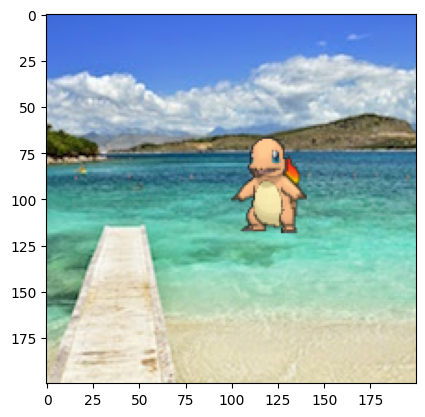

In [44]:
plt.imshow(xx[5])

In [55]:
model =make_model()
model.fit(pokemon_generator_bg(),steps_per_epoch = 50,epochs = 5)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 256s 4s/step - loss: 1.4869
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 203s 4s/step - loss: 0.9374
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 204s 4s/step - loss: 0.8962
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 204s 4s/step - loss: 0.8365
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 204s 4s/step - loss: 0.1951


In [66]:
from skimage.transform import resize

def pokemon_prediction_bg():
   bg_idx = np.random.choice(len(backgrounds))
   bg = backgrounds[bg_idx]
   bg_h,bg_w,_ = bg.shape
   rnd_h = np.random.randint(bg_h - poke_dim)
   rnd_w = np.random.randint(bg_w - poke_dim)
   x = bg[rnd_h:rnd_h+poke_dim,rnd_w:rnd_w+poke_dim].copy()

   appear = (np.random.random()<0.5)

   # Initialize alpha with a default value
   alpha = np.zeros((poke_dim,poke_dim,3))

   if appear:
    scale = 0.5 + np.random.random()
    new_height = int(ch_h*scale)
    new_width = int(ch_w*scale)
    if np.random.random()<0.5:
          obj = np.fliplr(ch)
    else:
          obj = ch
    obj = resize(
         obj, # Use the potentially flipped obj for resizing
         (new_height,new_width),
         preserve_range = True).astype(np.uint8)
    row0 = np.random.randint(poke_dim - new_height)
    col0 = np.random.randint(poke_dim - new_width)
    row1 = row0 + new_height
    col1 = col0 + new_width
    alpha = obj[:,:,3] / 255.0  # Normalize alpha to be between 0 and 1
    alpha = np.stack([alpha]*3, axis=-1) # Expand alpha to 3 channels

    bg_slice = x[row0:row1,col0:col1,:]
    obj_rgb = obj[:,:,:3]

       # Blend the images
    x[row0:row1,col0:col1,:] = (1.0 - alpha) * bg_slice + alpha * obj_rgb

  #predict
   x_expanded = np.expand_dims(x,0)/255.
   p = model.predict(x_expanded)[0]

  # draw box

   fig,ax = plt.subplots(1)
   ax.imshow(x.astype(np.uint8))
   if p[4]>0.5:
    row0_pred = int(p[0]*poke_dim)
    col0_pred = int(p[1]*poke_dim)
    row1_pred = int(row0_pred + p[2]*poke_dim)
    col1_pred = int(col0_pred + p[3]*poke_dim)
    print('pred:',row0_pred,col0_pred,row1_pred,col1_pred)
  #print('loss:', -np.mean(y*np.log(p) + (1-y)*np.log(1-p)))
    rect = Rectangle(
       (p[1]*poke_dim,p[0]*poke_dim),
       p[3]*poke_dim,p[ 2]*poke_dim,linewidth = 1,edgecolor = 'r',facecolor = 'none')
    ax.add_patch(rect)
   else:
    print('pred: no object')
   plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
pred: 104 60 184 104


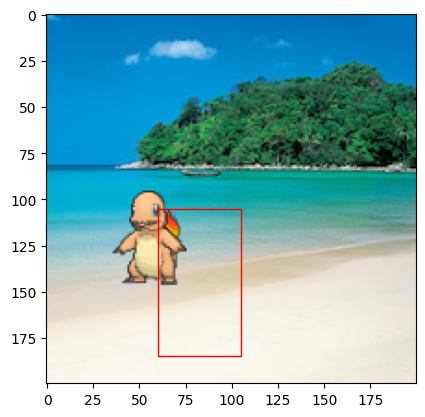

In [74]:
pokemon_prediction_bg()